In [1]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 73.3 MB/s eta 0:00:00


In [2]:
import sys
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss

GROUND_TRUTH_DIR = Path("/kaggle/input/datasets/khanhngnguynl/eval-1/ground_truth/ground_truth")

PATHS = {
    "fashion_clip": {
        "embedding": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/fc/cropped_embeddings.npy",
        "metadata": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/fc/metadata.csv",
    },
    "resnet50": {
        "embedding": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/resnet50/cropped_embeddings.npy",
        "metadata": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/resnet50/metadata.csv",
    },
    "efficientnet_b0": {
        "embedding": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/efficientnet_b0/cropped_embeddings.npy",
        "metadata": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/efficientnet_b0/metadata.csv",
    },
    "vgg16": {
        "embedding": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/vgg16/cropped_embeddings.npy",
        "metadata": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/vgg16/metadata.csv",
    },
    "vit_b16": {
        "embedding": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/vit_b_16/cropped_embeddings.npy",
        "metadata": "/kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/vit_b_16/metadata.csv",
    },
}

MODEL_DISPLAY_NAMES = {
    "fashion_clip": "Fashion-CLIP",
    "resnet50": "ResNet50",
    "efficientnet_b0": "EfficientNet-B0",
    "vgg16": "VGG16",
    "vit_b16": "ViT-B/16",
}
MODELS = ["fashion_clip", "resnet50", "efficientnet_b0", "vgg16", "vit_b16"]

OUTPUT_DIR = Path("/kaggle/working/retrieval_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KS = (1, 5, 10, 20)
NORM_TOLERANCE = 1e-3

for name, p in PATHS.items():
    emb_exists = Path(p["embedding"]).exists()
    meta_exists = Path(p["metadata"]).exists()
    print(f"{name:20s} embedding exists={emb_exists}  metadata exists={meta_exists}")

fashion_clip         embedding exists=True  metadata exists=True
resnet50             embedding exists=True  metadata exists=True
efficientnet_b0      embedding exists=True  metadata exists=True
vgg16                embedding exists=True  metadata exists=True
vit_b16              embedding exists=True  metadata exists=True


In [3]:
from pathlib import Path
import pandas as pd


def load_fashionclip_metadata(metadata_csv):
    """
    Load metadata Fashion-CLIP và cập nhật image path từ root cũ
    sang root dataset hiện tại trên Kaggle.

    Không sửa file metadata gốc.
    """

    metadata_csv = Path(metadata_csv)

    if not metadata_csv.exists():
        raise FileNotFoundError(
            f"Không tìm thấy metadata file:\n{metadata_csv}"
        )

    # =========================
    # 1. Load metadata
    # =========================
    df = pd.read_csv(metadata_csv)

    print("Metadata shape:", df.shape)
    print("Columns:", df.columns.tolist())

    required_cols = {"image_id", "image_path"}

    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(
            f"Metadata thiếu các cột bắt buộc: {missing_cols}"
        )

    # =========================
    # 2. Root path cũ / mới
    # =========================

    OLD_ROOT = Path(
        "/kaggle/input/datasets/khanhngnguynl/deepfashion/images"
    )

    NEW_ROOT = Path(
        "/kaggle/input/datasets/khanhngnguynl/deepfashion/deepfashion/images"
    )

    print("\nOLD_ROOT:")
    print(OLD_ROOT)

    print("\nNEW_ROOT:")
    print(NEW_ROOT)

    # =========================
    # 3. Update path
    # =========================

    def update_image_path(path):
        path = Path(str(path))

        try:
            relative_path = path.relative_to(OLD_ROOT)
            return str(NEW_ROOT / relative_path)

        except ValueError:
            # Nếu path không bắt đầu bằng OLD_ROOT
            # thì giữ nguyên
            return str(path)

    df["image_path_updated"] = df["image_path"].apply(update_image_path)

    # =========================
    # 4. Kiểm tra tồn tại
    # =========================

    df["old_path_exists"] = df["image_path"].apply(
        lambda x: Path(str(x)).exists()
    )

    df["new_path_exists"] = df["image_path_updated"].apply(
        lambda x: Path(str(x)).exists()
    )

    # =========================
    # 5. Summary
    # =========================

    print("\n========== PATH VALIDATION ==========")

    print(
        "Old path exists:",
        df["old_path_exists"].sum(),
        "/",
        len(df)
    )

    print(
        "Updated path exists:",
        df["new_path_exists"].sum(),
        "/",
        len(df)
    )

    print("\nSample:")

    print(
        df[
            [
                "image_id",
                "image_path",
                "image_path_updated",
                "new_path_exists"
            ]
        ].head()
    )

    # =========================
    # 6. Validation
    # =========================

    missing_paths = df[~df["new_path_exists"]]

    if len(missing_paths) > 0:
        print(
            f"\n[WARNING] Có {len(missing_paths)} ảnh "
            "không tìm thấy sau khi update path."
        )

        print("\n20 path lỗi đầu tiên:")

        print(
            missing_paths[
                [
                    "image_id",
                    "image_path",
                    "image_path_updated"
                ]
            ].head(20)
        )

    else:
        print(
            "\n[OK] Tất cả image path sau khi update đều tồn tại."
        )

    return df.reset_index(drop=True)

In [4]:
def load_ground_truth(ground_truth_dir):
    query_path = ground_truth_dir / "query.csv"
    gallery_path = ground_truth_dir / "gallery.csv"
    gt_path = ground_truth_dir / "ground_truth.csv"

    for p in [query_path, gallery_path, gt_path]:
        if not p.exists():
            raise FileNotFoundError(f"Không tìm thấy: {p}")

    query_df = pd.read_csv(query_path)
    gallery_df = pd.read_csv(gallery_path)
    gt_df = pd.read_csv(gt_path)

    print("=" * 50)
    print("LOAD GROUND TRUTH")
    print("=" * 50)
    print()
    print("query.csv shape :", query_df.shape)
    print("Columns:", list(query_df.columns))
    print(query_df.head())
    print()
    print("gallery.csv shape :", gallery_df.shape)
    print("Columns:", list(gallery_df.columns))
    print(gallery_df.head())
    print()
    print("ground_truth.csv shape :", gt_df.shape)
    print("Columns:", list(gt_df.columns))
    print(gt_df.head())

    return query_df, gallery_df, gt_df


query_df_raw, gallery_df, gt_df = load_ground_truth(GROUND_TRUTH_DIR)

# --- Derive "valid" query set: chỉ những query có >=1 positive trong ground_truth.csv ---
# (query.csv chứa toàn bộ 3540 query đã exact-match với In-shop, nhưng chỉ 1890 trong
#  số đó có positive gallery -> đây mới là valid query dùng để evaluation)
valid_query_ids = set(gt_df["query_image_id"].unique())
valid_query_df = query_df_raw[query_df_raw["dfm_image_id"].isin(valid_query_ids)].reset_index(drop=True)

print("\n" + "=" * 50)
print("SOFT VALIDATION (chỉ WARNING, không crash)")
print("=" * 50)

expected_counts = {"valid_query": 1890, "gallery": 2944, "gt_pairs": 4697}
actual_counts = {"valid_query": len(valid_query_df), "gallery": len(gallery_df), "gt_pairs": len(gt_df)}

for key in expected_counts:
    if actual_counts[key] != expected_counts[key]:
        print(f"[WARNING] {key}: expected {expected_counts[key]}, got {actual_counts[key]}")
    else:
        print(f"{key}: OK ({actual_counts[key]})")

# --- Data quality checks ---
print("\n--- Data quality checks ---")

dup_query = query_df_raw["dfm_image_id"].duplicated().sum()
dup_gallery = gallery_df["dfm_image_id"].duplicated().sum()
print(f"Duplicate dfm_image_id trong query.csv   : {dup_query}")
print(f"Duplicate dfm_image_id trong gallery.csv : {dup_gallery}")

null_query = query_df_raw["dfm_image_id"].isna().sum()
null_gallery = gallery_df["dfm_image_id"].isna().sum()
print(f"Null image ID trong query.csv   : {null_query}")
print(f"Null image ID trong gallery.csv : {null_gallery}")

n_query_without_gt = len(query_df_raw) - len(valid_query_df)
print(f"Query không có GT (bị loại khỏi evaluation) : {n_query_without_gt}")

gt_gallery_ids_not_in_gallery = set(gt_df["positive_gallery_image_id"]) - set(gallery_df["dfm_image_id"])
print(f"GT gallery ID không nằm trong gallery.csv : {len(gt_gallery_ids_not_in_gallery)}")
if gt_gallery_ids_not_in_gallery:
    print("  Sample:", list(gt_gallery_ids_not_in_gallery)[:10])

print(f"\nSố valid query sẽ dùng cho evaluation: {len(valid_query_df)}")

LOAD GROUND TRUTH

query.csv shape : (1890, 9)
Columns: ['query_index', 'dfm_image_id', 'dfm_image_path', 'dfm_item_id', 'inshop_item_id', 'inshop_image_name', 'evaluation_status', 'mapping_level', 'mapping_confidence']
   query_index                           dfm_image_id  \
0            1  MEN-Denim-id_00000353-02_7_additional   
1            2  MEN-Denim-id_00000826-04_7_additional   
2            3  MEN-Denim-id_00000938-03_7_additional   
3            4  MEN-Denim-id_00001198-01_7_additional   
4            5  MEN-Denim-id_00001198-03_7_additional   

                                      dfm_image_path  dfm_item_id  \
0  /kaggle/input/datasets/khanhngnguynl/deepfashi...  id_00000353   
1  /kaggle/input/datasets/khanhngnguynl/deepfashi...  id_00000826   
2  /kaggle/input/datasets/khanhngnguynl/deepfashi...  id_00000938   
3  /kaggle/input/datasets/khanhngnguynl/deepfashi...  id_00001198   
4  /kaggle/input/datasets/khanhngnguynl/deepfashi...  id_00001198   

  inshop_item_id      

In [5]:
def load_model_embeddings(model_name, embedding_path, metadata_path, norm_tolerance=NORM_TOLERANCE):
    embedding_path = Path(embedding_path)
    metadata_path = Path(metadata_path)

    if not embedding_path.exists():
        raise FileNotFoundError(f"[{model_name}] Không tìm thấy embedding: {embedding_path}")
    if not metadata_path.exists():
        raise FileNotFoundError(f"[{model_name}] Không tìm thấy metadata: {metadata_path}")

    embeddings = np.load(embedding_path)
    metadata_df = pd.read_csv(metadata_path)

    print(f"\n--- {model_name} ---")
    print("Embedding shape :", embeddings.shape)
    print("Metadata length :", len(metadata_df))

    assert len(metadata_df) == embeddings.shape[0], (
        f"[{model_name}] len(metadata)={len(metadata_df)} != len(embedding)={embeddings.shape[0]}"
    )

    has_nan = bool(np.isnan(embeddings).any())
    has_inf = bool(np.isinf(embeddings).any())
    print("NaN  :", has_nan)
    print("Inf  :", has_inf)
    print("dtype:", embeddings.dtype)

    assert not has_nan, f"[{model_name}] Embedding chứa NaN"
    assert not has_inf, f"[{model_name}] Embedding chứa Inf"

    norms = np.linalg.norm(embeddings, axis=1)
    mean_norm, min_norm, max_norm = norms.mean(), norms.min(), norms.max()
    print(f"Norm - mean: {mean_norm:.6f}  min: {min_norm:.6f}  max: {max_norm:.6f}")

    if abs(mean_norm - 1.0) > norm_tolerance or abs(max_norm - 1.0) > norm_tolerance:
        print(f"[WARNING] Norm lệch quá tolerance ({norm_tolerance}) -> tiến hành L2 normalize lại.")
        embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms_after = np.linalg.norm(embeddings, axis=1)
        print(f"Norm sau khi re-normalize - mean: {norms_after.mean():.6f}")
    else:
        print("Norm nằm trong tolerance -> KHÔNG normalize lại (giữ nguyên embedding gốc).")

    if embeddings.dtype != np.float32:
        embeddings = embeddings.astype(np.float32)

    return embeddings, metadata_df


# Load thử để kiểm tra trước khi chạy full loop ở Cell 7
embeddings_cache = {}
metadata_cache = {}

for model_key in MODELS:
    emb, meta = load_model_embeddings(
        model_key, PATHS[model_key]["embedding"], PATHS[model_key]["metadata"]
    )
    embeddings_cache[model_key] = emb
    metadata_cache[model_key] = meta


--- fashion_clip ---
Embedding shape : (12701, 512)
Metadata length : 12701
NaN  : False
Inf  : False
dtype: float32
Norm - mean: 1.000000  min: 1.000000  max: 1.000000
Norm nằm trong tolerance -> KHÔNG normalize lại (giữ nguyên embedding gốc).

--- resnet50 ---
Embedding shape : (12701, 2048)
Metadata length : 12701
NaN  : False
Inf  : False
dtype: float32
Norm - mean: 1.000000  min: 1.000000  max: 1.000000
Norm nằm trong tolerance -> KHÔNG normalize lại (giữ nguyên embedding gốc).

--- efficientnet_b0 ---
Embedding shape : (12701, 1280)
Metadata length : 12701
NaN  : False
Inf  : False
dtype: float32
Norm - mean: 1.000000  min: 1.000000  max: 1.000000
Norm nằm trong tolerance -> KHÔNG normalize lại (giữ nguyên embedding gốc).

--- vgg16 ---
Embedding shape : (12701, 4096)
Metadata length : 12701
NaN  : False
Inf  : False
dtype: float32
Norm - mean: 1.000000  min: 1.000000  max: 1.000000
Norm nằm trong tolerance -> KHÔNG normalize lại (giữ nguyên embedding gốc).

--- vit_b16 ---
Embe

In [6]:
def map_embedding_indices(image_df, id_column, metadata_df, model_name=""):

    dup_meta = metadata_df["image_id"].duplicated().sum()
    if dup_meta > 0:
        print(f"[WARNING] [{model_name}] metadata có {dup_meta} duplicate image_id "
              f"-> chỉ dùng row đầu tiên cho mỗi image_id.")

    image_id_to_index = {}
    for idx, image_id in enumerate(metadata_df["image_id"]):
        if image_id not in image_id_to_index:
            image_id_to_index[image_id] = idx

    df = image_df.copy()
    df["embedding_index"] = df[id_column].map(image_id_to_index)

    missing_mask = df["embedding_index"].isna()
    n_missing = int(missing_mask.sum())
    n_total = len(df)

    if n_missing > 0:
        print(f"[{model_name}] Mapped: {n_total - n_missing} / {n_total}")
        print(f"[{model_name}] 20 image ID đầu tiên KHÔNG map được:")
        print(df.loc[missing_mask, id_column].head(20).tolist())
        raise ValueError(
            f"[{model_name}] {n_missing}/{n_total} ID không map được vào embedding index. "
            f"Yêu cầu 100% phải map được - KHÔNG được silently drop."
        )

    df["embedding_index"] = df["embedding_index"].astype(int)
    print(f"[{model_name}] Mapped: {n_total}/{n_total} (100%)")
    return df


# Test mapping cho cả 5 model (query + gallery), dùng valid_query_df và gallery_df chung
print("=" * 50)
print("MAP IMAGE ID -> EMBEDDING INDEX (per model)")
print("=" * 50)

query_mapped_cache = {}
gallery_mapped_cache = {}

for model_key in MODELS:
    print(f"\n--- {model_key} ---")
    q_mapped = map_embedding_indices(
        valid_query_df, "dfm_image_id", metadata_cache[model_key], model_name=f"{model_key}/query"
    )
    g_mapped = map_embedding_indices(
        gallery_df, "dfm_image_id", metadata_cache[model_key], model_name=f"{model_key}/gallery"
    )
    query_mapped_cache[model_key] = q_mapped
    gallery_mapped_cache[model_key] = g_mapped

MAP IMAGE ID -> EMBEDDING INDEX (per model)

--- fashion_clip ---
[fashion_clip/query] Mapped: 1890/1890 (100%)
[fashion_clip/gallery] Mapped: 2944/2944 (100%)

--- resnet50 ---
[resnet50/query] Mapped: 1890/1890 (100%)
[resnet50/gallery] Mapped: 2944/2944 (100%)

--- efficientnet_b0 ---
[efficientnet_b0/query] Mapped: 1890/1890 (100%)
[efficientnet_b0/gallery] Mapped: 2944/2944 (100%)

--- vgg16 ---
[vgg16/query] Mapped: 1890/1890 (100%)
[vgg16/gallery] Mapped: 2944/2944 (100%)

--- vit_b16 ---
[vit_b16/query] Mapped: 1890/1890 (100%)
[vit_b16/gallery] Mapped: 2944/2944 (100%)


In [7]:
def build_positive_dict(gt_df, valid_query_ids):
    positive_dict = (
        gt_df.groupby("query_image_id")["positive_gallery_image_id"]
        .apply(set)
        .to_dict()
    )

    # Validate: mọi query trong valid_query_ids phải có >=1 positive
    missing_positive = valid_query_ids - set(positive_dict.keys())
    if missing_positive:
        raise ValueError(
            f"{len(missing_positive)} valid query KHÔNG có positive trong positive_dict. "
            f"Sample: {list(missing_positive)[:10]}"
        )

    counts = [len(v) for v in positive_dict.values()]
    print("=" * 50)
    print("POSITIVE SET SUMMARY")
    print("=" * 50)
    print(f"Số query trong positive_dict : {len(positive_dict)}")
    print(f"Số valid query mong đợi      : {len(valid_query_ids)}")
    print(f"Min positives/query  : {min(counts)}")
    print(f"Max positives/query  : {max(counts)}")
    print(f"Mean positives/query : {np.mean(counts):.4f}")

    return positive_dict


positive_dict = build_positive_dict(gt_df, valid_query_ids)

POSITIVE SET SUMMARY
Số query trong positive_dict : 1890
Số valid query mong đợi      : 1890
Min positives/query  : 1
Max positives/query  : 15
Mean positives/query : 2.4852


In [8]:
def evaluate_model(
    model_name,
    embeddings,
    query_mapped_df,
    gallery_mapped_df,
    positive_dict,
    ks=KS,
):

    query_embeddings = np.ascontiguousarray(
        embeddings[query_mapped_df["embedding_index"].values], dtype=np.float32
    )
    gallery_embeddings = np.ascontiguousarray(
        embeddings[gallery_mapped_df["embedding_index"].values], dtype=np.float32
    )

    dim = gallery_embeddings.shape[1]

    # --- Build index ---
    t0 = time.time()
    index = faiss.IndexFlatIP(dim)
    index.add(gallery_embeddings)
    index_build_time = time.time() - t0

    # --- Full-gallery search (dùng cho cả Recall@K và mAP) ---
    n_gallery = gallery_embeddings.shape[0]
    t0 = time.time()
    scores, indices = index.search(query_embeddings, n_gallery)
    search_time = time.time() - t0

    n_queries = query_embeddings.shape[0]
    queries_per_sec = n_queries / search_time if search_time > 0 else float("inf")

    gallery_image_ids = gallery_mapped_df["dfm_image_id"].values
    gallery_item_ids = gallery_mapped_df["dfm_item_id"].values if "dfm_item_id" in gallery_mapped_df.columns else None

    query_image_ids = query_mapped_df["dfm_image_id"].values
    query_item_ids = query_mapped_df["dfm_item_id"].values if "dfm_item_id" in query_mapped_df.columns else None

    # --- Recall@K ---
    recall_at_k = {}
    for k in ks:
        hits = 0
        for qi in range(n_queries):
            positives = positive_dict.get(query_image_ids[qi], set())
            topk_ids = gallery_image_ids[indices[qi, :k]]
            if any(gid in positives for gid in topk_ids):
                hits += 1
        recall_at_k[k] = hits / n_queries

    # --- AP / mAP (full ranking, đúng công thức cho multi-positive) ---
    ap_list = []
    rr_list = []
    top20_records = []

    for qi in range(n_queries):
        query_image_id = query_image_ids[qi]
        query_item_id = query_item_ids[qi] if query_item_ids is not None else None
        positives = positive_dict.get(query_image_id, set())
        num_relevant = len(positives)

        ranked_ids = gallery_image_ids[indices[qi]]
        ranked_scores = scores[qi]

        found = 0
        precision_sum = 0.0
        first_relevant_rank = None

        for rank, gid in enumerate(ranked_ids, start=1):
            is_positive = gid in positives
            if is_positive:
                found += 1
                precision_sum += found / rank
                if first_relevant_rank is None:
                    first_relevant_rank = rank

            if rank <= 20:
                retrieved_item_id = (
                    gallery_item_ids[indices[qi, rank - 1]] if gallery_item_ids is not None else None
                )
                top20_records.append({
                    "query_image_id": query_image_id,
                    "query_item_id": query_item_id,
                    "rank": rank,
                    "retrieved_image_id": gid,
                    "retrieved_item_id": retrieved_item_id,
                    "similarity_score": float(ranked_scores[rank - 1]),
                    "is_positive": bool(is_positive),
                })

        ap = precision_sum / num_relevant if num_relevant > 0 else 0.0
        ap_list.append(ap)

        rr = 1.0 / first_relevant_rank if first_relevant_rank is not None else 0.0
        rr_list.append(rr)

    mAP = float(np.mean(ap_list))
    MRR = float(np.mean(rr_list))

    metrics = {
        "Model": MODEL_DISPLAY_NAMES.get(model_name, model_name),
        "Dimension": dim,
        "Queries": n_queries,
        "Gallery": n_gallery,
        "Recall@1": recall_at_k[1],
        "Recall@5": recall_at_k[5],
        "Recall@10": recall_at_k[10],
        "Recall@20": recall_at_k[20],
        "mAP": mAP,
        "MRR": MRR,
        "Index Build Time (s)": index_build_time,
        "Search Time (s)": search_time,
        "Queries/sec": queries_per_sec,
    }

    top20_df = pd.DataFrame(top20_records)

    print(f"\nModel: {metrics['Model']}")
    print(f"Embedding dim: {dim}")
    print(f"Queries: {n_queries}")
    print(f"Gallery: {n_gallery}")
    print()
    print(f"Index build time: {index_build_time:.4f}s")
    print(f"Search time: {search_time:.4f}s")
    print(f"Queries/sec: {queries_per_sec:.2f}")
    print()
    print(f"Recall@1: {recall_at_k[1]:.4f}")
    print(f"Recall@5: {recall_at_k[5]:.4f}")
    print(f"Recall@10: {recall_at_k[10]:.4f}")
    print(f"Recall@20: {recall_at_k[20]:.4f}")
    print(f"mAP: {mAP:.4f}")
    print(f"MRR: {MRR:.4f}")

    return metrics, top20_df

In [9]:
print("=" * 50)
print("RUNNING RETRIEVAL EVALUATION FOR 5 MODELS")
print("=" * 50)

results_rows = []
top20_dfs = {}

for model_key in MODELS:
    print("\n" + "=" * 60)
    print(MODEL_DISPLAY_NAMES[model_key])
    print("=" * 60)

    metrics, top20_df = evaluate_model(
        model_name=model_key,
        embeddings=embeddings_cache[model_key],
        query_mapped_df=query_mapped_cache[model_key],
        gallery_mapped_df=gallery_mapped_cache[model_key],
        positive_dict=positive_dict,
        ks=KS,
    )

    results_rows.append(metrics)
    top20_dfs[model_key] = top20_df

RUNNING RETRIEVAL EVALUATION FOR 5 MODELS

Fashion-CLIP

Model: Fashion-CLIP
Embedding dim: 512
Queries: 1890
Gallery: 2944

Index build time: 0.0016s
Search time: 0.3300s
Queries/sec: 5727.62

Recall@1: 0.6164
Recall@5: 0.7857
Recall@10: 0.8370
Recall@20: 0.8847
mAP: 0.5837
MRR: 0.6943

ResNet50

Model: ResNet50
Embedding dim: 2048
Queries: 1890
Gallery: 2944

Index build time: 0.0182s
Search time: 0.3963s
Queries/sec: 4769.16

Recall@1: 0.4090
Recall@5: 0.5847
Recall@10: 0.6598
Recall@20: 0.7381
mAP: 0.3824
MRR: 0.4966

EfficientNet-B0

Model: EfficientNet-B0
Embedding dim: 1280
Queries: 1890
Gallery: 2944

Index build time: 0.0050s
Search time: 0.3918s
Queries/sec: 4824.17

Recall@1: 0.4608
Recall@5: 0.6386
Recall@10: 0.7011
Recall@20: 0.7630
mAP: 0.4253
MRR: 0.5429

VGG16

Model: VGG16
Embedding dim: 4096
Queries: 1890
Gallery: 2944

Index build time: 0.0426s
Search time: 0.4877s
Queries/sec: 3875.10

Recall@1: 0.3434
Recall@5: 0.5238
Recall@10: 0.5947
Recall@20: 0.6545
mAP: 0.3195

In [10]:
results_df = pd.DataFrame(results_rows)

# Giữ đúng thứ tự yêu cầu
display_order = [MODEL_DISPLAY_NAMES[m] for m in MODELS]
results_df["Model"] = pd.Categorical(results_df["Model"], categories=display_order, ordered=True)
results_df = results_df.sort_values("Model").reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
print("=" * 50)
print("FINAL RESULTS TABLE")
print("=" * 50)
print(results_df.to_string(index=False))

results_df

FINAL RESULTS TABLE
          Model  Dimension  Queries  Gallery  Recall@1  Recall@5  Recall@10  Recall@20      mAP      MRR  Index Build Time (s)  Search Time (s)  Queries/sec
   Fashion-CLIP        512     1890     2944  0.616402  0.785714   0.837037   0.884656 0.583745 0.694337              0.001639         0.329980  5727.621651
       ResNet50       2048     1890     2944  0.408995  0.584656   0.659788   0.738095 0.382432 0.496588              0.018157         0.396296  4769.162152
EfficientNet-B0       1280     1890     2944  0.460847  0.638624   0.701058   0.762963 0.425327 0.542900              0.004969         0.391777  4824.172460
          VGG16       4096     1890     2944  0.343386  0.523810   0.594709   0.654497 0.319494 0.427178              0.042568         0.487730  3875.098407
       ViT-B/16        768     1890     2944  0.413757  0.593651   0.670899   0.733333 0.390731 0.500002              0.002956         0.329843  5729.998048


,Model,Dimension,Queries,Gallery,Recall@1,Recall@5,Recall@10,Recall@20,mAP,MRR,Index Build Time (s),Search Time (s),Queries/sec
0,Fashion-CLIP,512,1890,2944,0.616402,0.785714,0.837037,0.884656,0.583745,0.694337,0.001639,0.329980,5727.621651
1,ResNet50,2048,1890,2944,0.408995,0.584656,0.659788,0.738095,0.382432,0.496588,0.018157,0.396296,4769.162152
2,EfficientNet-B0,1280,1890,2944,0.460847,0.638624,0.701058,0.762963,0.425327,0.542900,0.004969,0.391777,4824.172460
3,VGG16,4096,1890,2944,0.343386,0.523810,0.594709,0.654497,0.319494,0.427178,0.042568,0.487730,3875.098407
4,ViT-B/16,768,1890,2944,0.413757,0.593651,0.670899,0.733333,0.390731,0.500002,0.002956,0.329843,5729.998048


In [11]:
results_csv_path = OUTPUT_DIR / "model_comparison.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"Đã lưu: {results_csv_path}")

for model_key in MODELS:
    top20_path = OUTPUT_DIR / f"{model_key}_top20.csv"
    top20_dfs[model_key].to_csv(top20_path, index=False)
    print(f"Đã lưu: {top20_path} ({len(top20_dfs[model_key])} rows)")

Đã lưu: /kaggle/working/retrieval_results/model_comparison.csv
Đã lưu: /kaggle/working/retrieval_results/fashion_clip_top20.csv (37800 rows)
Đã lưu: /kaggle/working/retrieval_results/resnet50_top20.csv (37800 rows)
Đã lưu: /kaggle/working/retrieval_results/efficientnet_b0_top20.csv (37800 rows)
Đã lưu: /kaggle/working/retrieval_results/vgg16_top20.csv (37800 rows)
Đã lưu: /kaggle/working/retrieval_results/vit_b16_top20.csv (37800 rows)


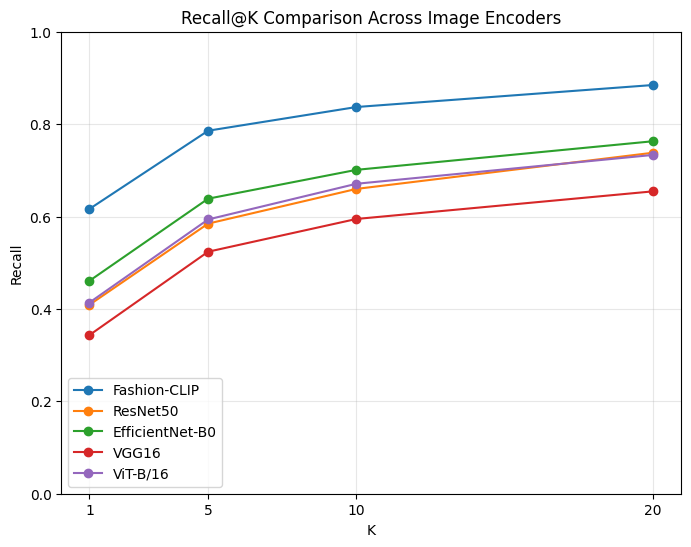

Đã lưu: /kaggle/working/retrieval_results/recall_comparison.png


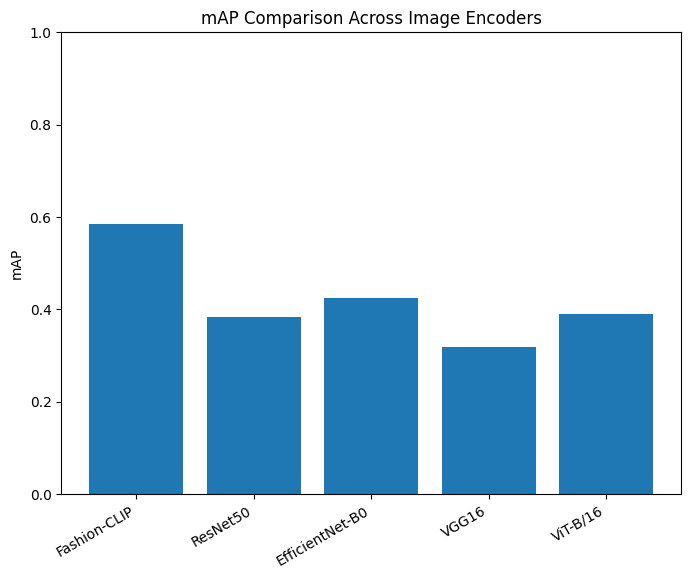

Đã lưu: /kaggle/working/retrieval_results/map_comparison.png


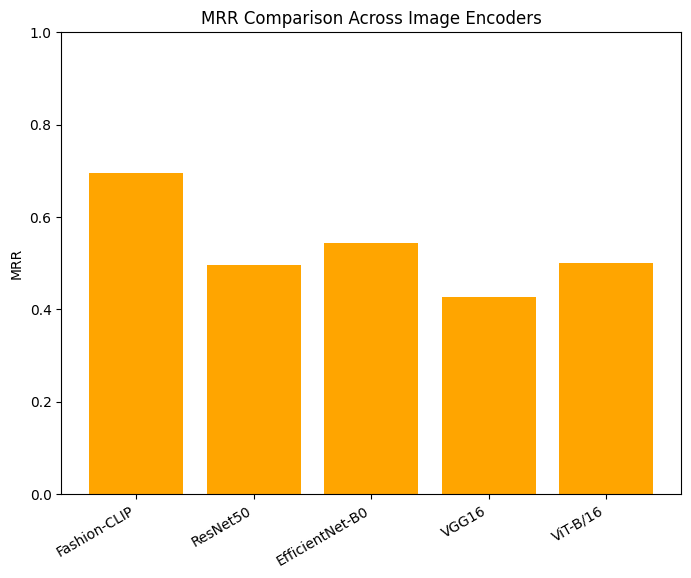

In [12]:
# --- CHART 1: Recall@K comparison (line chart) ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
k_values = list(KS)

for _, row in results_df.iterrows():
    recall_values = [row[f"Recall@{k}"] for k in k_values]
    ax1.plot(k_values, recall_values, marker="o", label=row["Model"])

ax1.set_xlabel("K")
ax1.set_ylabel("Recall")
ax1.set_title("Recall@K Comparison Across Image Encoders")
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)

recall_chart_path = OUTPUT_DIR / "recall_comparison.png"
fig1.savefig(recall_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {recall_chart_path}")

# --- CHART 2: mAP comparison (bar chart) ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.bar(results_df["Model"].astype(str), results_df["mAP"])
ax2.set_ylabel("mAP")
ax2.set_title("mAP Comparison Across Image Encoders")
ax2.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")

map_chart_path = OUTPUT_DIR / "map_comparison.png"
fig2.savefig(map_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {map_chart_path}")

# --- CHART 3 (optional): MRR comparison (bar chart) ---
fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.bar(results_df["Model"].astype(str), results_df["MRR"], color="orange")
ax3.set_ylabel("MRR")
ax3.set_title("MRR Comparison Across Image Encoders")
ax3.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

In [13]:
print("=" * 50)
print("SANITY CHECK")
print("=" * 50)

errors = []

# 1. 5 model đều được evaluate
if len(results_df) != 5:
    errors.append(f"Chỉ có {len(results_df)}/5 model được evaluate.")

# 2. Không model nào có NaN metric
metric_cols = ["Recall@1", "Recall@5", "Recall@10", "Recall@20", "mAP", "MRR"]
for _, row in results_df.iterrows():
    for col in metric_cols:
        if pd.isna(row[col]):
            errors.append(f"[{row['Model']}] {col} là NaN")

# 3. Recall@1 <= Recall@5 <= Recall@10 <= Recall@20
for _, row in results_df.iterrows():
    values = [row["Recall@1"], row["Recall@5"], row["Recall@10"], row["Recall@20"]]
    if not all(values[i] <= values[i + 1] + 1e-9 for i in range(len(values) - 1)):
        errors.append(f"[{row['Model']}] Recall@K không monotonic tăng: {values}")

# 4. Metrics nằm trong [0,1]
for _, row in results_df.iterrows():
    for col in metric_cols:
        if not (0.0 <= row[col] <= 1.0 + 1e-9):
            errors.append(f"[{row['Model']}] {col}={row[col]} nằm ngoài [0,1]")

# 5. Query count giống nhau giữa 5 model
if results_df["Queries"].nunique() != 1:
    errors.append(f"Query count KHÔNG giống nhau giữa các model: {results_df[['Model','Queries']].to_dict('records')}")

# 6. Gallery count giống nhau giữa 5 model
if results_df["Gallery"].nunique() != 1:
    errors.append(f"Gallery count KHÔNG giống nhau giữa các model: {results_df[['Model','Gallery']].to_dict('records')}")

# 7. 100% query có positive GT
if len(valid_query_df) != len(positive_dict):
    errors.append(f"Không phải 100% valid query có positive GT: "
                  f"{len(valid_query_df)} valid query vs {len(positive_dict)} trong positive_dict")

# 8. Không có query/gallery embedding mapping bị thiếu
for model_key in MODELS:
    q_missing = query_mapped_cache[model_key]["embedding_index"].isna().sum()
    g_missing = gallery_mapped_cache[model_key]["embedding_index"].isna().sum()
    if q_missing > 0 or g_missing > 0:
        errors.append(f"[{model_key}] query_missing={q_missing}, gallery_missing={g_missing}")

if errors:
    print(f"\n[FAILED] Tìm thấy {len(errors)} lỗi:\n")
    for e in errors:
        print(" -", e)
else:
    print("\n[PASSED] Tất cả sanity check đều hợp lệ.")

print("\n" + "=" * 50)

SANITY CHECK

[PASSED] Tất cả sanity check đều hợp lệ.



In [14]:
np.random.seed(42)

fashion_clip_top20 = top20_dfs["fashion_clip"]
sample_query_ids = np.random.choice(
    fashion_clip_top20["query_image_id"].unique(), size=5, replace=False
)

print("=" * 60)
print("QUALITATIVE CHECK - Fashion-CLIP (5 random queries)")
print("=" * 60)

for query_image_id in sample_query_ids:
    print(f"\nQuery:")
    print(f"  {query_image_id}")

    print(f"\nGround Truth (positive gallery):")
    for pos_id in sorted(positive_dict.get(query_image_id, set())):
        print(f"  {pos_id}")

    print(f"\nTop-10 retrieved:")
    query_results = fashion_clip_top20[
        fashion_clip_top20["query_image_id"] == query_image_id
    ].sort_values("rank").head(10)

    for _, row in query_results.iterrows():
        marker = "  <-- POSITIVE" if row["is_positive"] else ""
        print(f"  rank {row['rank']:2d} | {row['retrieved_image_id']:50s} | "
              f"score={row['similarity_score']:.4f}{marker}")

    print("-" * 60)

QUALITATIVE CHECK - Fashion-CLIP (5 random queries)

Query:
  WOMEN-Rompers_Jumpsuits-id_00007521-02_3_back

Ground Truth (positive gallery):
  WOMEN-Rompers_Jumpsuits-id_00007521-02_1_front
  WOMEN-Rompers_Jumpsuits-id_00007521-02_2_side

Top-10 retrieved:
  rank  1 | WOMEN-Rompers_Jumpsuits-id_00007521-02_2_side      | score=0.9211  <-- POSITIVE
  rank  2 | WOMEN-Rompers_Jumpsuits-id_00007669-04_3_back      | score=0.8392
  rank  3 | WOMEN-Rompers_Jumpsuits-id_00000957-02_2_side      | score=0.8391
  rank  4 | WOMEN-Dresses-id_00000912-04_2_side                | score=0.8367
  rank  5 | WOMEN-Rompers_Jumpsuits-id_00001548-05_1_front     | score=0.8302
  rank  6 | WOMEN-Pants-id_00003829-01_1_front                 | score=0.8287
  rank  7 | WOMEN-Rompers_Jumpsuits-id_00007669-04_2_side      | score=0.8275
  rank  8 | WOMEN-Blouses_Shirts-id_00003257-04_7_additional   | score=0.8267
  rank  9 | WOMEN-Rompers_Jumpsuits-id_00002176-06_7_additional | score=0.8209
  rank 10 | WOMEN-Rompers

In [15]:
# Fashion-CLIP Cropped path đã có trong PATHS["fashion_clip"] ở config cũ -> reuse, không khai báo lại.
FASHION_CLIP_ORIGINAL_EMBEDDING_PATH = Path(
    "/kaggle/input/datasets/khanhngnguynl/deepfashion/results/data/processed/embeddings/original_embeddings.npy"
)
FASHION_CLIP_METADATA_PATH = Path(PATHS["fashion_clip"]["metadata"])  # cùng metadata.csv với cropped

print("Fashion-CLIP Original embedding path :", FASHION_CLIP_ORIGINAL_EMBEDDING_PATH)
print("  exists:", FASHION_CLIP_ORIGINAL_EMBEDDING_PATH.exists())
print("Fashion-CLIP Cropped embedding path  :", PATHS["fashion_clip"]["embedding"])
print("  exists:", Path(PATHS["fashion_clip"]["embedding"]).exists())
print("Metadata path (dùng chung)           :", FASHION_CLIP_METADATA_PATH)
print("  exists:", FASHION_CLIP_METADATA_PATH.exists())

Fashion-CLIP Original embedding path : /kaggle/input/datasets/khanhngnguynl/deepfashion/results/data/processed/embeddings/original_embeddings.npy
  exists: True
Fashion-CLIP Cropped embedding path  : /kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/fc/cropped_embeddings.npy
  exists: True
Metadata path (dùng chung)           : /kaggle/input/datasets/khanhngnguynl/eval-1/embeddings/embeddings/fc/metadata.csv
  exists: True


In [16]:
original_embeddings, original_metadata_df = load_model_embeddings(
    "fashion_clip_original",
    FASHION_CLIP_ORIGINAL_EMBEDDING_PATH,
    FASHION_CLIP_METADATA_PATH,
)

print("\n--- Kiểm tra shape kỳ vọng ---")
expected_shape = (12701, 512)
if original_embeddings.shape != expected_shape:
    print(f"[WARNING] Shape thực tế {original_embeddings.shape} khác kỳ vọng {expected_shape}")
else:
    print(f"Shape OK: {original_embeddings.shape}")

assert len(original_metadata_df) == len(original_embeddings), (
    f"len(metadata)={len(original_metadata_df)} != len(original_embeddings)={len(original_embeddings)}"
)
print("len(metadata) == len(original_embeddings): OK")


--- fashion_clip_original ---
Embedding shape : (12701, 512)
Metadata length : 12701
NaN  : False
Inf  : False
dtype: float32
Norm - mean: 1.000000  min: 1.000000  max: 1.000000
Norm nằm trong tolerance -> KHÔNG normalize lại (giữ nguyên embedding gốc).

--- Kiểm tra shape kỳ vọng ---
Shape OK: (12701, 512)
len(metadata) == len(original_embeddings): OK


In [17]:
# Map query/gallery -> embedding_index riêng cho Fashion-CLIP Original
# (dùng lại metadata Fashion-CLIP vì Original và Cropped row-aligned trên cùng metadata.csv,
#  nhưng vẫn map tường minh qua image_id, không giả định trực tiếp)
query_mapped_original = map_embedding_indices(
    valid_query_df, "dfm_image_id", original_metadata_df, model_name="fashion_clip_original/query"
)
gallery_mapped_original = map_embedding_indices(
    gallery_df, "dfm_image_id", original_metadata_df, model_name="fashion_clip_original/gallery"
)

print("\n" + "=" * 60)
print("Fashion-CLIP Original")
print("=" * 60)

metrics_original, top20_original_df = evaluate_model(
    model_name="fashion_clip_original",
    embeddings=original_embeddings,
    query_mapped_df=query_mapped_original,
    gallery_mapped_df=gallery_mapped_original,
    positive_dict=positive_dict,
    ks=KS,
)

# evaluate_model dùng MODEL_DISPLAY_NAMES.get(...) để đặt tên hiển thị; model_name
# "fashion_clip_original" không có trong dict đó nên Model sẽ giữ nguyên "fashion_clip_original".
# Đặt lại tên hiển thị rõ ràng cho các bước so sánh sau:
metrics_original["Model"] = "Fashion-CLIP Original"

[fashion_clip_original/query] Mapped: 1890/1890 (100%)
[fashion_clip_original/gallery] Mapped: 2944/2944 (100%)

Fashion-CLIP Original

Model: fashion_clip_original
Embedding dim: 512
Queries: 1890
Gallery: 2944

Index build time: 0.0015s
Search time: 0.3191s
Queries/sec: 5922.99

Recall@1: 0.7365
Recall@5: 0.8667
Recall@10: 0.8942
Recall@20: 0.9270
mAP: 0.7036
MRR: 0.7960


In [18]:
# Lấy kết quả Fashion-CLIP Cropped đã có sẵn từ results_df (benchmark 5 model trước đó) - KHÔNG chạy lại.
cropped_row = results_df[results_df["Model"] == "Fashion-CLIP"].iloc[0].to_dict()
cropped_row["Model"] = "Fashion-CLIP Cropped"

compare_rows = [
    {**metrics_original, "Variant": metrics_original["Model"]},
    {**cropped_row, "Variant": cropped_row["Model"]},
]

comparison_df = pd.DataFrame(compare_rows)

# Sắp xếp lại cột theo đúng yêu cầu, bỏ cột "Model" trùng lặp với "Variant"
comparison_columns = [
    "Variant", "Dimension", "Queries", "Gallery",
    "Recall@1", "Recall@5", "Recall@10", "Recall@20",
    "mAP", "MRR", "Index Build Time (s)", "Search Time (s)", "Queries/sec",
]
comparison_df = comparison_df[comparison_columns]

print("=" * 50)
print("FASHION-CLIP: ORIGINAL vs CROPPED")
print("=" * 50)
print(comparison_df.to_string(index=False))

comparison_df

FASHION-CLIP: ORIGINAL vs CROPPED
              Variant  Dimension  Queries  Gallery  Recall@1  Recall@5  Recall@10  Recall@20      mAP      MRR  Index Build Time (s)  Search Time (s)  Queries/sec
Fashion-CLIP Original        512     1890     2944  0.736508  0.866667   0.894180   0.926984 0.703650 0.796034              0.001479         0.319095  5922.994061
 Fashion-CLIP Cropped        512     1890     2944  0.616402  0.785714   0.837037   0.884656 0.583745 0.694337              0.001639         0.329980  5727.621651


,Variant,Dimension,Queries,Gallery,Recall@1,Recall@5,Recall@10,Recall@20,mAP,MRR,Index Build Time (s),Search Time (s),Queries/sec
0,Fashion-CLIP Original,512,1890,2944,0.736508,0.866667,0.894180,0.926984,0.703650,0.796034,0.001479,0.319095,5922.994061
1,Fashion-CLIP Cropped,512,1890,2944,0.616402,0.785714,0.837037,0.884656,0.583745,0.694337,0.001639,0.329980,5727.621651


In [19]:
original_metrics_row = comparison_df[comparison_df["Variant"] == "Fashion-CLIP Original"].iloc[0]
cropped_metrics_row = comparison_df[comparison_df["Variant"] == "Fashion-CLIP Cropped"].iloc[0]

metric_names = ["Recall@1", "Recall@5", "Recall@10", "Recall@20", "mAP", "MRR"]

delta_records = []
for metric in metric_names:
    original_value = original_metrics_row[metric]
    cropped_value = cropped_metrics_row[metric]
    delta = cropped_value - original_value
    relative_improvement = (delta / original_value * 100) if original_value != 0 else float("nan")

    delta_records.append({
        "Metric": metric,
        "Original": original_value,
        "Cropped": cropped_value,
        "Delta (absolute)": delta,
        "Relative improvement (%)": relative_improvement,
    })

delta_df = pd.DataFrame(delta_records)

print("=" * 70)
print("DELTA ANALYSIS")
print("=" * 70)
print(f"{'Metric':<12} {'Original':>10} {'Cropped':>10} {'Delta':>10} {'Relative %':>12}")
for _, row in delta_df.iterrows():
    print(f"{row['Metric']:<12} {row['Original']:>10.4f} {row['Cropped']:>10.4f} "
          f"{row['Delta (absolute)']:>+10.4f} {row['Relative improvement (%)']:>+11.2f}%")

delta_df

DELTA ANALYSIS
Metric         Original    Cropped      Delta   Relative %
Recall@1         0.7365     0.6164    -0.1201      -16.31%
Recall@5         0.8667     0.7857    -0.0810       -9.34%
Recall@10        0.8942     0.8370    -0.0571       -6.39%
Recall@20        0.9270     0.8847    -0.0423       -4.57%
mAP              0.7036     0.5837    -0.1199      -17.04%
MRR              0.7960     0.6943    -0.1017      -12.78%


,Metric,Original,Cropped,Delta (absolute),Relative improvement (%)
0,Recall@1,0.736508,0.616402,-0.120106,-16.307471
1,Recall@5,0.866667,0.785714,-0.080952,-9.340659
2,Recall@10,0.894180,0.837037,-0.057143,-6.390533
3,Recall@20,0.926984,0.884656,-0.042328,-4.566210
4,mAP,0.703650,0.583745,-0.119905,-17.040400
5,MRR,0.796034,0.694337,-0.101698,-12.775527
